# PCA Encoder

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import json

def plot_learning_curve(train_curve_path, val_curve_path=None, ax=None, title=""):

    if os.path.exists(train_curve_path):
        with open(train_curve_path, 'r') as file:
            train_curve = json.load(file)
    if val_curve_path is not None and os.path.exists(val_curve_path):
        with open(val_curve_path, 'r') as file:
            val_curve = json.load(file)

    if ax is None:
        fig, ax = plt.subplots()
    epochs = np.arange(1,len(train_curve)+1,1)
    ax.plot(epochs, train_curve, label='train')
    if val_curve_path is not None:
        ax.plot(epochs, val_curve, label='val')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.set_title(f'Learning curve {title}')
    ax.legend()
    plt.tight_layout()
    plt.show()

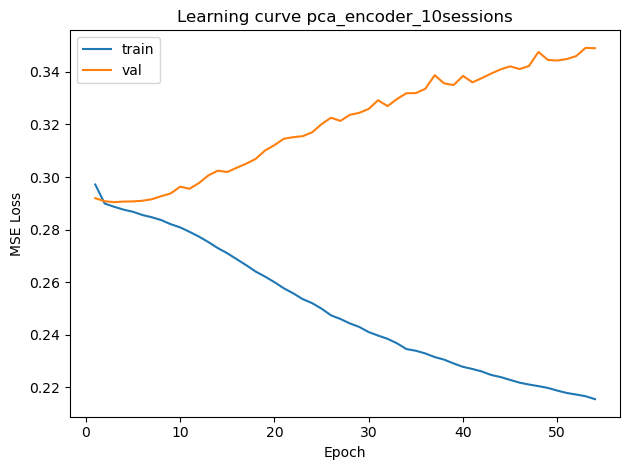

Loading existing mean image
Loading existing PCA model


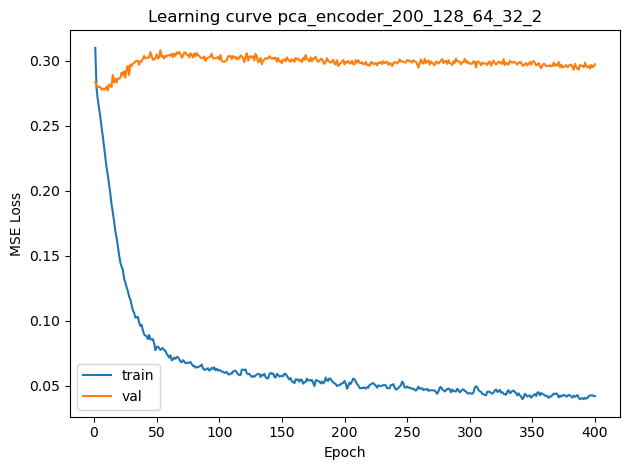

In [38]:
from pca_encoder import PCAEncoder

pca_models_path = os.path.join(os.getcwd(), "pca_models")
for model_name in os.listdir(pca_models_path):
    model_path = os.path.join(pca_models_path, model_name)
    if os.path.isdir(model_path):
        if model_name == "pca_encoder_200_128_64_32_2":
            model = PCAEncoder(model_name=model_name, output_dim=2)
            model.load_model()

        train_curve_path = os.path.join(model_path, "train_curve.json")
        val_curve_path = os.path.join(model_path, "val_curve.json")
        # print(train_curve_path)
        # with open(train_curve_path, 'r') as file:
        #     train_curve = json.load(file)
        #     print(train_curve)
        if os.path.exists(val_curve_path):
            plot_learning_curve(train_curve_path, val_curve_path, title=model_name)
        else:
            plot_learning_curve(train_curve_path, title=model_name)

In [9]:
from torch.utils.data import DataLoader
from torchvision import transforms
import torch
from gripper_data import GripperDataset

# data
top_img_shape = np.array([720, 1280])
resize_factor = 4
resize_shape = [x for x in map(int,top_img_shape/resize_factor)]
print(f"Resizing images to {resize_shape}")
preprocess = transforms.Compose([
        transforms.ToTensor(),
        transforms.Resize(resize_shape),
        # transforms.ConvertImageDtype(torch.float16),
        transforms.Lambda(lambda x: torch.flatten(x))
        ])
batch_size = 128 #int(os.getenv("BATCH_SIZE"))
print(f"Batch size: {batch_size}")
sessions = np.arange(1,2) # sessions to load
path = os.getenv("DATASET_PATH") # experiment path
dataset = GripperDataset(abs_path=path, 
                            sessions=sessions, 
                            transform=preprocess,
                            images_to_load=["Top_masks_processed"])
# split = [0.9, 0.1] # train, val
# train_dataset, val_dataset = torch.utils.data.random_split(dataset, split)
split = [0.8, 0.1, 0.1] # train, val, test
train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(dataset, split)
train_loader = DataLoader(train_dataset, 
                        batch_size=batch_size, 
                        shuffle=True)
val_loader = DataLoader(val_dataset,
                        batch_size=batch_size)

Resizing images to [180, 320]
Batch size: 128


In [39]:
import numpy as np

batch = next(iter(train_loader))
model.architecture.eval()
criterion = torch.nn.MSELoss()
with torch.no_grad():
    # batch = batch.to(DEVICE)
    images, states = batch
    states = states[:,:model.output_dim]
    pca_projections = (images - model.mean) @ model.eigenvectors.T
    output = model(pca_projections)
    loss = criterion(output, states)
    print(f"RMSE Loss: {np.sqrt(loss.item())}")
    for o,s in zip(output, states):
        print(f"Output: {o.numpy()}, State: {s.numpy()}")

RMSE Loss: 0.07573379881816532
Output: [0.8828231  0.23161992], State: [0.8464286 0.2132143]
Output: [0.9102528  0.92074275], State: [0.8987857 0.9250714]
Output: [0.88073087 0.41098398], State: [0.88928574 0.42242858]
Output: [0.74045765 0.36797535], State: [0.7327143 0.3627143]
Output: [0.61643845 0.5138644 ], State: [0.63464284 0.53114283]
Output: [0.6876757 0.5172032], State: [0.70257145 0.49028572]
Output: [0.3359765  0.31092572], State: [0.39457142 0.276     ]
Output: [0.4096956  0.24440238], State: [0.4087143  0.25628573]
Output: [0.63534784 0.53530705], State: [0.6275714  0.52757144]
Output: [0.33004993 0.9908055 ], State: [0.37757143 0.967     ]
Output: [0.09982243 0.85287464], State: [0.01257143 0.8320714 ]
Output: [0.33083528 0.00190502], State: [0.32435715 0.0035    ]
Output: [-0.12259379  0.36711225], State: [-0.07185714  0.4062857 ]
Output: [0.12734164 0.7519802 ], State: [0.137 0.773]
Output: [0.7750753 0.5470866], State: [0.7275     0.54285717]
Output: [-0.09807527  0.6